In [1]:
pip install mlxtend


[notice] A new release of pip is available: 23.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules

In [3]:
pd.read_csv(r"D:\current documents\Desktop\Final project\dirty_v3_path.csv")

,Age,Gender,Medical Condition,Glucose,Blood Pressure,BMI,Oxygen Saturation,LengthOfStay,Cholesterol,Triglycerides,HbA1c,Smoking,Alcohol,Physical Activity,Diet Score,Family History,Stress Level,Sleep Hours,random_notes,noise_col
0,46.0,Male,Diabetes,137.04,135.27,28.90,96.04,6,231.88,210.56,7.61,0,0,-0.20,3.54,0,5.07,6.05,lorem,-137.057211
1,22.0,Male,Healthy,71.58,113.27,26.29,97.54,2,165.57,129.41,4.91,0,0,8.12,5.90,0,5.87,7.72,ipsum,-11.230610
2,50.0,NaN,Asthma,95.24,NaN,22.53,90.31,2,214.94,165.35,5.60,0,0,5.01,4.65,1,3.09,4.82,ipsum,98.331195
3,57.0,NaN,Obesity,NaN,130.53,38.47,96.60,5,197.71,182.13,6.92,0,0,3.16,3.37,0,3.01,5.33,lorem,44.187175
4,66.0,Female,Hypertension,95.15,178.17,31.12,94.90,4,259.53,115.85,5.98,0,1,3.56,3.40,0,6.38,6.64,lorem,44.831426
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,54.0,Female,Healthy,86.35,127.68,28.30,94.36,1,218.60,152.82,4.85,0,0,9.15,10.35,0,3.65,8.71,ipsum,89.573837
29996,41.0,Male,Asthma,89.24,154.37,24.93,96.07,4,198.30,176.81,5.36,1,0,3.34,3.40,0,6.72,2.81,lorem,-5.864517
29997,83.0,Female,NaN,NaN,170.11,30.55,97.83,3,210.13,168.76,5.05,0,0,4.53,4.50,0,4.31,3.61,###,-30.934595
29998,41.0,Male,Diabetes,242.87,152.97,23.57,99.17,3,208.86,224.21,7.59,0,0,3.16,2.59,0,7.10,5.80,ipsum,5.085258


In [4]:
Health_care=pd.read_csv(r"D:\current documents\Desktop\Final project\dirty_v3_path.csv")

In [5]:
Health_care.drop(['random_notes','noise_col'], axis=1, inplace=True)

In [6]:
Health_care = Health_care.dropna(subset=['Medical Condition'])

In [7]:
# numerical columnsFill with median
num_cols = ['Age','Glucose','Blood Pressure']
for col in num_cols:
    Health_care[col].fillna(Health_care[col].median(), inplace=True)
#Gender → use mode

# categorical
Health_care['Gender'].fillna(Health_care['Gender'].mode()[0], inplace=True)

C:\Users\admin\AppData\Local\Temp\ipykernel_19740\543019867.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  Health_care[col].fillna(Health_care[col].median(), inplace=True)
C:\Users\admin\AppData\Local\Temp\ipykernel_19740\543019867.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a 

In [7]:
Health_care

,Age,Gender,Medical Condition,Glucose,Blood Pressure,BMI,Oxygen Saturation,LengthOfStay,Cholesterol,Triglycerides,HbA1c,Smoking,Alcohol,Physical Activity,Diet Score,Family History,Stress Level,Sleep Hours
0,46.0,Male,Diabetes,137.04,135.270,28.90,96.04,6,231.88,210.56,7.61,0,0,-0.20,3.54,0,5.07,6.05
1,22.0,Male,Healthy,71.58,113.270,26.29,97.54,2,165.57,129.41,4.91,0,0,8.12,5.90,0,5.87,7.72
2,50.0,Female,Asthma,95.24,138.285,22.53,90.31,2,214.94,165.35,5.60,0,0,5.01,4.65,1,3.09,4.82
3,57.0,Female,Obesity,110.51,130.530,38.47,96.60,5,197.71,182.13,6.92,0,0,3.16,3.37,0,3.01,5.33
4,66.0,Female,Hypertension,95.15,178.170,31.12,94.90,4,259.53,115.85,5.98,0,1,3.56,3.40,0,6.38,6.64
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29994,76.0,Female,Hypertension,97.17,138.920,25.65,93.99,3,235.65,238.26,6.43,0,0,3.14,3.46,0,6.66,6.10
29995,54.0,Female,Healthy,86.35,127.680,28.30,94.36,1,218.60,152.82,4.85,0,0,9.15,10.35,0,3.65,8.71
29996,41.0,Male,Asthma,89.24,154.370,24.93,96.07,4,198.30,176.81,5.36,1,0,3.34,3.40,0,6.72,2.81
29998,41.0,Male,Diabetes,242.87,152.970,23.57,99.17,3,208.86,224.21,7.59,0,0,3.16,2.59,0,7.10,5.80


In [8]:
Important_feature = Health_care[['BMI', 'Blood Pressure', 'Cholesterol', 'Medical Condition']]

In [9]:
# Convert Numerical Data into Categories
def bmi_category(bmi):
    if bmi < 25:
        return 'Normal_BMI'
    elif bmi < 30:
        return 'Overweight'
    else:
        return 'Obese'

Health_care['BMI_Category'] = Health_care['BMI'].apply(bmi_category)

In [10]:
#blood pressure Categorization
def bp_category(bp):
    if bp < 120:
        return 'Normal_BP'
    elif bp < 140:
        return 'Elevated_BP'
    else:
        return 'High_BP'

Health_care['BP_Category'] = Health_care['Blood Pressure'].apply(bp_category)


#Convert Medical Conditions
Health_care['Medical Condition'] = Health_care['Medical Condition'].str.replace(" ", "_")

In [11]:
#Cholesterol Categorization
def cholesterol_category(ch):
    if ch < 200:
        return 'Normal_Cholesterol'
    elif ch < 240:
        return 'Borderline_Cholesterol'
    else:
        return 'High_Cholesterol'

Health_care['Cholesterol_Category'] = Health_care['Cholesterol'].apply(cholesterol_category)

In [12]:
#Create Final Transaction Dataset
transactions = Health_care[[
    'BMI_Category',
    'BP_Category',
    'Medical Condition',
    'Cholesterol_Category'
]] 

In [18]:
Health_care

,Age,Gender,Medical Condition,Glucose,Blood Pressure,BMI,Oxygen Saturation,LengthOfStay,Cholesterol,Triglycerides,...,Smoking,Alcohol,Physical Activity,Diet Score,Family History,Stress Level,Sleep Hours,BMI_Category,BP_Category,Cholesterol_Category
0,46.0,Male,Diabetes,137.04,135.270,28.90,96.04,6,231.88,210.56,...,0,0,-0.20,3.54,0,5.07,6.05,Overweight,Elevated_BP,Borderline_Cholesterol
1,22.0,Male,Healthy,71.58,113.270,26.29,97.54,2,165.57,129.41,...,0,0,8.12,5.90,0,5.87,7.72,Overweight,Normal_BP,Normal_Cholesterol
2,50.0,Female,Asthma,95.24,138.285,22.53,90.31,2,214.94,165.35,...,0,0,5.01,4.65,1,3.09,4.82,Normal_BMI,Elevated_BP,Borderline_Cholesterol
3,57.0,Female,Obesity,110.51,130.530,38.47,96.60,5,197.71,182.13,...,0,0,3.16,3.37,0,3.01,5.33,Obese,Elevated_BP,Normal_Cholesterol
4,66.0,Female,Hypertension,95.15,178.170,31.12,94.90,4,259.53,115.85,...,0,1,3.56,3.40,0,6.38,6.64,Obese,High_BP,High_Cholesterol
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29994,76.0,Female,Hypertension,97.17,138.920,25.65,93.99,3,235.65,238.26,...,0,0,3.14,3.46,0,6.66,6.10,Overweight,Elevated_BP,Borderline_Cholesterol
29995,54.0,Female,Healthy,86.35,127.680,28.30,94.36,1,218.60,152.82,...,0,0,9.15,10.35,0,3.65,8.71,Overweight,Elevated_BP,Borderline_Cholesterol
29996,41.0,Male,Asthma,89.24,154.370,24.93,96.07,4,198.30,176.81,...,1,0,3.34,3.40,0,6.72,2.81,Normal_BMI,High_BP,Normal_Cholesterol
29998,41.0,Male,Diabetes,242.87,152.970,23.57,99.17,3,208.86,224.21,...,0,0,3.16,2.59,0,7.10,5.80,Normal_BMI,High_BP,Borderline_Cholesterol


In [13]:
#Convert categories into binary format
encoded_df = pd.get_dummies(transactions)

In [17]:
print(encoded_df.head())

   BMI_Category_Normal_BMI  BMI_Category_Obese  BMI_Category_Overweight  \
0                    False               False                     True   
1                    False               False                     True   
2                     True               False                    False   
3                    False                True                    False   
4                    False                True                    False   

   BP_Category_Elevated_BP  BP_Category_High_BP  BP_Category_Normal_BP  \
0                     True                False                  False   
1                    False                False                   True   
2                     True                False                  False   
3                     True                False                  False   
4                    False                 True                  False   

   Medical Condition_Arthritis  Medical Condition_Asthma  \
0                        False              

In [14]:
#Apply Apriori Algorithm-find frequent pattern
frequent_items = apriori(
    encoded_df,
    min_support=0.05,
    use_colnames=True
)
#Generate Association Rules
rules = association_rules(
    frequent_items,
    metric="confidence",
    min_threshold=0.6
)
#rules
print(rules[['antecedents',
             'consequents',
             'support',
             'confidence',
             'lift']])
#sort best rules
rules = rules.sort_values(by='lift', ascending=False)
print(rules.head(10))
rules.to_csv("association_rules.csv", index=False)

                                          antecedents  \
0                         (Medical Condition_Healthy)   
1                         (Medical Condition_Obesity)   
2                    (Medical Condition_Hypertension)   
3                         (Medical Condition_Healthy)   
4   (BMI_Category_Normal_BMI, Medical Condition_He...   
5   (Medical Condition_Healthy, Cholesterol_Catego...   
6   (Medical Condition_Obesity, BP_Category_Elevat...   
7   (BMI_Category_Obese, Medical Condition_Hyperte...   
8   (Medical Condition_Obesity, Cholesterol_Catego...   
9   (BMI_Category_Overweight, Medical Condition_Hy...   
10  (Cholesterol_Category_High_Cholesterol, BMI_Ca...   
11  (Medical Condition_Healthy, BP_Category_Elevat...   
12  (Medical Condition_Hypertension, Cholesterol_C...   
13  (Cholesterol_Category_High_Cholesterol, BP_Cat...   
14  (Cholesterol_Category_High_Cholesterol, Medica...   

                                  consequents   support  confidence      lift  
0      

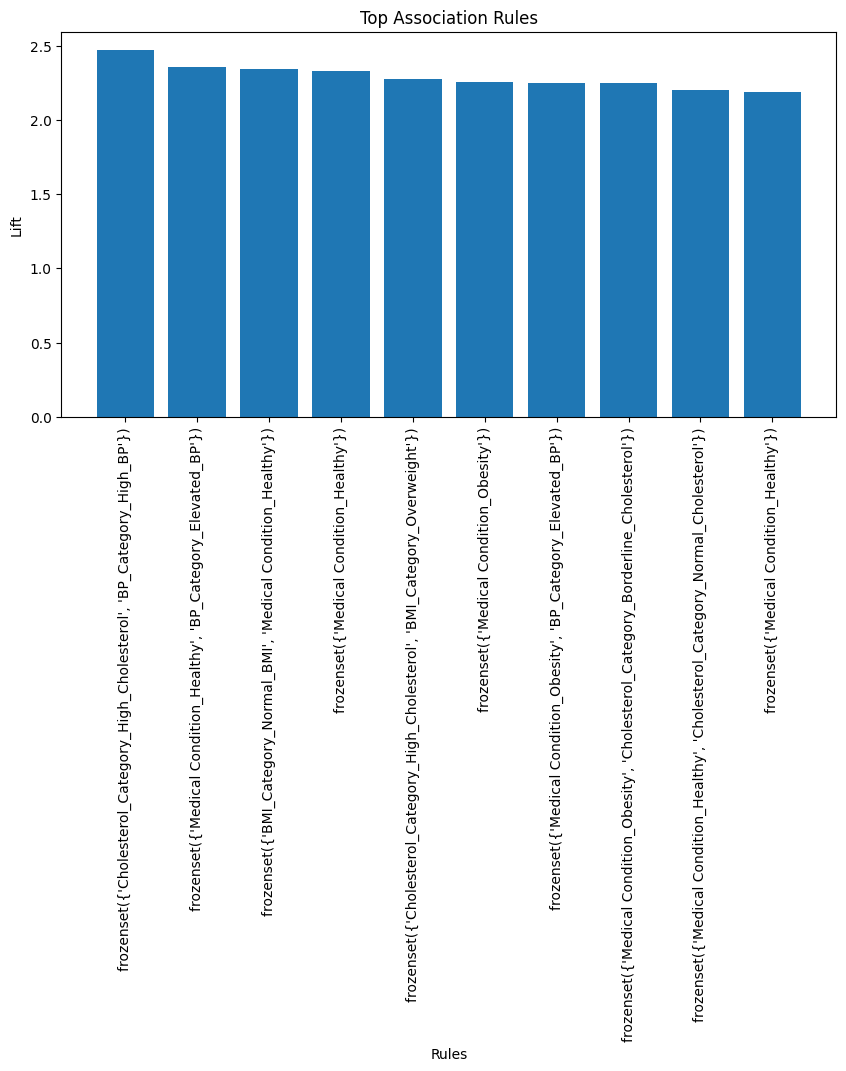

In [15]:
import matplotlib.pyplot as plt

top_rules = rules.head(10)

plt.figure(figsize=(10,5))
plt.bar(range(len(top_rules)), top_rules['lift'])
plt.xticks(range(len(top_rules)),
           top_rules['antecedents'].astype(str),
           rotation=90)

plt.xlabel("Rules")
plt.ylabel("Lift")
plt.title("Top Association Rules")
plt.show()